<a href="https://colab.research.google.com/github/Fedekasparian/Sistemas-inteligentes/blob/main/Notebook_AIyLLM_03_Transformers_espanol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Transformers paso a paso con BERT en español


Este notebook muestra paso a paso cómo funciona un modelo Transformer usando BERT multilingüe.
Incluye:

1. Tokenización
2. Embeddings
3. Encoding posicional
4. Mecanismo de atención
5. Visualización de atención
6. Aplicaciones reales: predicción de máscara y análisis de sentimiento

Librerías utilizadas: `transformers`, `torch`, `matplotlib`, `seaborn`


In [ ]:
!pip install transformers torch matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 54.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
from transformers import AutoTokenizer, AutoModel, pipeline
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

modelo_id = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(modelo_id)
model = AutoModel.from_pretrained(modelo_id, output_attentions=True, attn_implementation="eager")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

In [ ]:
frase = "Cuenta una historia."
tokens = tokenizer.tokenize(frase)
ids = tokenizer.encode(frase, return_tensors='pt')
print("🔤 Tokens:", tokens)
print("🆔 IDs:", ids)

🔤 Tokens: ['Cuenta', 'una', 'historia', '.']
🆔 IDs: tensor([[  101, 64011, 10153, 13418,   119,   102]])


In [ ]:
with torch.no_grad():
    salida = model(ids)

embedding_salida = salida.last_hidden_state
print("📐 Shape de embeddings de salida:", embedding_salida.shape)

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


📐 Shape de embeddings de salida: torch.Size([1, 6, 768])


In [ ]:
import math

def positional_encoding(seq_len, d_model):
    pe = torch.zeros(seq_len, d_model)
    position = torch.arange(0, seq_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

pe_demo = positional_encoding(seq_len=ids.shape[1], d_model=embedding_salida.shape[-1])
print("📐 Positional Encoding shape:", pe_demo.shape)


📐 Positional Encoding shape: torch.Size([6, 768])


In [ ]:

attentions = salida.attentions
att_layer = attentions[0]  # primera capa
print("🧠 Atención - shape [Capa 0]:", att_layer.shape)


🧠 Atención - shape [Capa 0]: torch.Size([1, 12, 6, 6])


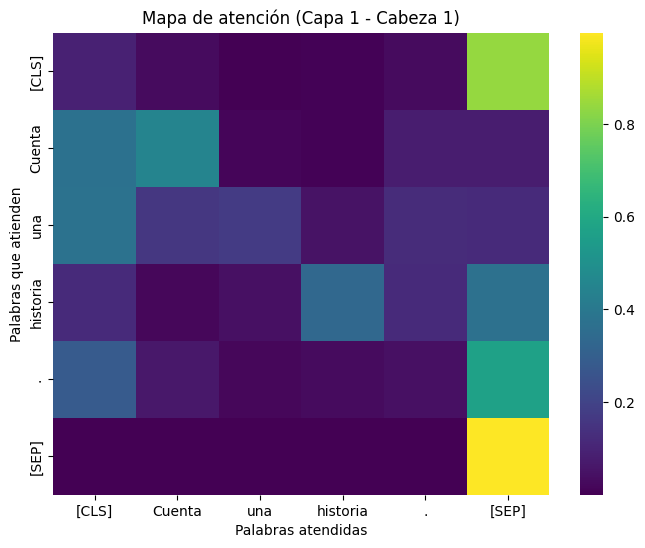

In [ ]:

atencion = attentions[0][0, 0]
tokens_vis = tokenizer.convert_ids_to_tokens(ids[0])

plt.figure(figsize=(8, 6))
sns.heatmap(atencion.numpy(), xticklabels=tokens_vis, yticklabels=tokens_vis, cmap='viridis')
plt.title("Mapa de atención (Capa 1 - Cabeza 1)")
plt.xlabel("Palabras atendidas")
plt.ylabel("Palabras que atienden")
plt.show()


In [ ]:

relleno = pipeline("fill-mask", model="bert-base-multilingual-cased", tokenizer="bert-base-multilingual-cased")
frase_mascara = "El [MASK] aprobó el crédito."
predicciones = relleno(frase_mascara)

for p in predicciones:
    print(f"🔍 {p['sequence']}")
    print(f"💡 Token predicho: {p['token_str']} | 🔢 score: {p['score']:.4f}\n")


Some weights of the model checkpoint at bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


🔍 Ello aprobó el crédito.
💡 Token predicho: ##lo | 🔢 score: 0.0712

🔍 El club aprobó el crédito.
💡 Token predicho: club | 🔢 score: 0.0639

🔍 El gobierno aprobó el crédito.
💡 Token predicho: gobierno | 🔢 score: 0.0431

🔍 El presidente aprobó el crédito.
💡 Token predicho: presidente | 🔢 score: 0.0291

🔍 El Público aprobó el crédito.
💡 Token predicho: Público | 🔢 score: 0.0228



In [ ]:

clasificador = pipeline("sentiment-analysis", model="pysentimiento/robertuito-sentiment-analysis")

textos = [
    "Me encanta este curso.",
    "Odio cuando no funciona el wifi.",
    "Está bien, pero podría ser mejor."
]

resultados = clasificador(textos)

for txt, res in zip(textos, resultados):
    print(f"📝 {txt}")
    print(f"➡️ Sentimiento: {res['label']} ({res['score']:.2f})\n")


config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Device set to use cpu


📝 Me encanta este curso.
➡️ Sentimiento: POS (0.96)

📝 Odio cuando no funciona el wifi.
➡️ Sentimiento: NEG (0.97)

📝 Está bien, pero podría ser mejor.
➡️ Sentimiento: NEU (0.63)

